# Explore `find_cenhaps.py` outputs

This notebook loads the standard TSV tables produced by `find_cenhaps.py` and makes quick summary views for CEN and periCEN runs. Edit `RUN_DIR` in the first code cell to point at the output folder you want to inspect.


In [1]:
from pathlib import Path
import os

# Keep matplotlib/IPython caches in a writable local temp area when running in jup5.
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/find_cenhaps_matplotlib")
os.environ.setdefault("IPYTHONDIR", "/private/tmp/find_cenhaps_ipython")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["IPYTHONDIR"]).mkdir(parents=True, exist_ok=True)

import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = Path.cwd()
OUTPUT_ROOT = ROOT / "outputs"

# Default to the local periCEN example if present. Change this to any find_cenhaps output folder.
RUN_DIR = OUTPUT_ROOT / "la5_cenhaps_from_fasta_pericen"
if not RUN_DIR.exists():
    RUN_DIR = None

SAVE_FIGURES = True
FIG_DIR_NAME = "notebook_figures"


## Find available runs

The table below lists output folders under `outputs/` and marks whether each expected table exists.


In [2]:
TABLE_SUFFIXES = {
    "stats": ".stats.txt",
    "kmer_summary": ".kmer_summary.tsv",
    "assigned_core_map": ".assigned_core_map.tsv",
    "cenhap_strength": ".cenhap_strength.tsv",
    "region_strength": ".region_strength.tsv",
    "paired_cen_pericen_strength": ".paired_cen_pericen_strength.tsv",
    "cen_pericen_independence": ".cen_pericen_independence.tsv",
    "relatedness_pairs": ".cen_relatedness.idf_weighted_pairs.tsv",
    "relatedness_matrix": ".cen_relatedness.idf_weighted_matrix.tsv",
    "cen_shared_kmers": ".cen_shared_kmers.tsv",
    "cen_shared_kmer_sets": ".cen_shared_kmer_sets.tsv",
    "cenhap_units": ".cenhap_units.tsv",
    "cenhap_unit_size_summary": ".cenhap_unit_size_summary.tsv",
    "cenhap_bins": ".cenhap_bins.tsv",
    "cenhap_windows": ".cenhap_windows.tsv",
    "cenhap_window_dispersion": ".cenhap_window_dispersion.tsv",
}


def first_matching(run_dir, suffix):
    matches = sorted(Path(run_dir).glob(f"*{suffix}"))
    return matches[0] if matches else None


def find_runs(output_root=OUTPUT_ROOT):
    rows = []
    if not output_root.exists():
        return pd.DataFrame()
    for run_dir in sorted(p for p in output_root.iterdir() if p.is_dir()):
        tsvs = sorted(run_dir.glob("*.tsv"))
        if not tsvs:
            continue
        row = {
            "run_dir": str(run_dir),
            "n_tsv": len(tsvs),
        }
        for name, suffix in TABLE_SUFFIXES.items():
            row[name] = first_matching(run_dir, suffix) is not None
        rows.append(row)
    return pd.DataFrame(rows)

runs = find_runs()
if runs.empty:
    display(Markdown("No `find_cenhaps.py` output folders were found under `outputs/`."))
else:
    display(runs.sort_values(["relatedness_matrix", "region_strength", "run_dir"], ascending=[False, False, True]))

if RUN_DIR is None:
    candidate = runs.loc[runs.get("relatedness_matrix", False) & runs.get("region_strength", False), "run_dir"] if not runs.empty else []
    RUN_DIR = Path(candidate.iloc[0]) if len(candidate) else (Path(runs.iloc[0]["run_dir"]) if not runs.empty else OUTPUT_ROOT)

RUN_DIR = Path(RUN_DIR)
FIG_DIR = RUN_DIR / FIG_DIR_NAME
if SAVE_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using RUN_DIR: {RUN_DIR}")


,run_dir,n_tsv,stats,kmer_summary,assigned_core_map,cenhap_strength,region_strength,paired_cen_pericen_strength,cen_pericen_independence,relatedness_pairs,relatedness_matrix,cen_shared_kmers,cen_shared_kmer_sets,cenhap_units,cenhap_unit_size_summary,cenhap_bins,cenhap_windows,cenhap_window_dispersion
4,/Users/lucacomai/Documents/Data_analysis_23/fi...,19,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,/Users/lucacomai/Documents/Data_analysis_23/fi...,14,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True
3,/Users/lucacomai/Documents/Data_analysis_23/fi...,16,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True
5,/Users/lucacomai/Documents/Data_analysis_23/fi...,16,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True
6,/Users/lucacomai/Documents/Data_analysis_23/fi...,16,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True
7,/Users/lucacomai/Documents/Data_analysis_23/fi...,16,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True
8,/Users/lucacomai/Documents/Data_analysis_23/fi...,14,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True
9,/Users/lucacomai/Documents/Data_analysis_23/fi...,14,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True
10,/Users/lucacomai/Documents/Data_analysis_23/fi...,14,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True
0,/Users/lucacomai/Documents/Data_analysis_23/fi...,10,True,True,True,True,False,False,False,False,False,False,False,True,True,True,True,True


Using RUN_DIR: /Users/lucacomai/Documents/Data_analysis_23/find_cenhaps/outputs/la5_cenhaps_from_fasta_pericen


## Load tables

Only tables present in `RUN_DIR` are loaded. Missing periCEN tables are expected for CEN-only runs.


In [3]:
def load_find_cenhaps_tables(run_dir):
    tables = {}
    paths = {}
    for name, suffix in TABLE_SUFFIXES.items():
        path = first_matching(run_dir, suffix)
        if path is None:
            continue
        paths[name] = path
        if suffix.endswith(".tsv"):
            tables[name] = pd.read_csv(path, sep="	")
    return tables, paths


tables, paths = load_find_cenhaps_tables(RUN_DIR)

overview = pd.DataFrame([
    {
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "path": str(paths[name]),
    }
    for name, df in tables.items()
])

display(overview.sort_values("table") if not overview.empty else overview)

for key in ["region_strength", "paired_cen_pericen_strength", "cen_pericen_independence", "relatedness_pairs", "relatedness_matrix"]:
    if key in tables:
        display(Markdown(f"### `{key}`"))
        display(tables[key].head(10))


,table,rows,columns,path
1,assigned_core_map,23461,9,/Users/lucacomai/Documents/Data_analysis_23/fi...
5,cen_pericen_independence,12,10,/Users/lucacomai/Documents/Data_analysis_23/fi...
9,cen_shared_kmer_sets,3343,9,/Users/lucacomai/Documents/Data_analysis_23/fi...
8,cen_shared_kmers,7110,36,/Users/lucacomai/Documents/Data_analysis_23/fi...
12,cenhap_bins,339,13,/Users/lucacomai/Documents/Data_analysis_23/fi...
2,cenhap_strength,24,7,/Users/lucacomai/Documents/Data_analysis_23/fi...
11,cenhap_unit_size_summary,24,14,/Users/lucacomai/Documents/Data_analysis_23/fi...
10,cenhap_units,911,10,/Users/lucacomai/Documents/Data_analysis_23/fi...
14,cenhap_window_dispersion,24,23,/Users/lucacomai/Documents/Data_analysis_23/fi...
13,cenhap_windows,2561,17,/Users/lucacomai/Documents/Data_analysis_23/fi...


### `region_strength`

,assigned_cen,region_class,chr,region_start,region_end,region_length_bp,selected_distinct_kmers,selected_distinct_kmers_per_mb,target_map_hits,target_map_hits_per_mb,cenhap_strength_units,cenhap_strength_units_per_mb,cenhap_strength_blocks,cenhap_strength_blocks_per_mb,block_bp,block_bp_fraction,mean_distinct_kmers_per_block
0,CEN1,CEN,Chr1,39038122,40481181,1443060,508,352.029715,2855,1978.434715,188,130.278713,1146,794.145774,44628,0.030926,2.491274
1,PERICEN1,PERICEN,Chr1,37038122,42481181,4000000,10,2.500000,88,22.000000,8,2.000000,64,16.000000,1712,0.000428,1.375000
2,CEN2,CEN,Chr2,16255916,17959473,1703558,1,0.587007,4,2.348027,1,0.587007,4,2.348027,92,0.000054,1.000000
3,PERICEN2,PERICEN,Chr2,14255916,19959473,4000000,144,36.000000,3206,801.500000,37,9.250000,2322,580.500000,62636,0.015659,1.380706
4,CEN3,CEN,Chr3,13060998,14390115,1329118,430,323.522817,5231,3935.692692,196,147.466214,3277,2465.544820,97221,0.073147,1.596277
5,PERICEN3,PERICEN,Chr3,11060998,16390115,4000000,17,4.250000,124,31.000000,11,2.750000,109,27.250000,2657,0.000664,1.137615
6,CEN4,CEN,Chr4,13368778,15335853,1967076,1381,702.057267,9845,5004.890508,308,156.577580,2714,1379.712833,139492,0.070913,3.627487
7,PERICEN4,PERICEN,Chr4,11368778,17335853,4000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0.000000
8,CEN5,CEN,Chr5,26943203,28208956,1265754,11,8.690472,54,42.662318,8,6.320343,40,31.601717,1060,0.000837,1.350000
9,PERICEN5,PERICEN,Chr5,24943203,30208956,4000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0.000000


### `paired_cen_pericen_strength`

,chr,cen_region,pericen_region,cen_region_length_bp,pericen_region_length_bp,cen_cenhap_strength_units_per_mb,pericen_cenhap_strength_units_per_mb,pericen_to_cen_units_per_mb_ratio,cen_selected_distinct_kmers_per_mb,pericen_selected_distinct_kmers_per_mb,pericen_to_cen_selected_kmers_per_mb_ratio,stronger_region_by_units_per_mb
0,Chr1,CEN1,PERICEN1,1443060,4000000,130.278713,2.00,0.015352,352.029715,2.50,0.007102,CEN1
1,Chr2,CEN2,PERICEN2,1703558,4000000,0.587007,9.25,15.757912,0.587007,36.00,61.328088,PERICEN2
2,Chr3,CEN3,PERICEN3,1329118,4000000,147.466214,2.75,0.018648,323.522817,4.25,0.013137,CEN3
3,Chr4,CEN4,PERICEN4,1967076,4000000,156.577580,0.00,0.000000,702.057267,0.00,0.000000,CEN4
4,Chr5,CEN5,PERICEN5,1265754,4000000,6.320343,0.00,0.000000,8.690472,0.00,0.000000,CEN5
5,Chr6,CEN6,PERICEN6,1256734,4000000,46.151373,0.50,0.010834,142.432687,2.00,0.014042,CEN6
6,Chr7,CEN7,PERICEN7,1715729,4000000,0.000000,0.25,inf,0.000000,0.25,inf,PERICEN7
7,Chr8,CEN8,PERICEN8,1660441,4000000,0.602250,0.25,0.415110,0.602250,0.25,0.415110,CEN8
8,Chr9,CEN9,PERICEN9,1688676,4000000,4.145259,0.00,0.000000,6.513979,0.00,0.000000,CEN9
9,Chr10,CEN10,PERICEN10,1772716,4000000,4.512849,0.75,0.166192,6.205168,1.25,0.201445,CEN10


...

,chr,cen_region,pericen_region,same_chrom_cen_pericen_relatedness,mean_cen_to_other_pericens_relatedness,same_chrom_vs_cen_to_other_pericens_ratio,mean_pericen_to_other_cens_relatedness,same_chrom_vs_pericen_to_other_cens_ratio,mean_pericen_to_other_pericens_relatedness,mean_cen_to_other_cens_relatedness
0,Chr1,CEN1,PERICEN1,0.263397,0.068171,3.863794,0.228513,1.152657,0.119029,0.228023
1,Chr2,CEN2,PERICEN2,0.049811,0.126090,0.395043,0.042695,1.166673,0.038462,0.179094
2,Chr3,CEN3,PERICEN3,0.000196,0.000547,0.358725,0.205415,0.000956,0.111648,0.000039
3,Chr4,CEN4,PERICEN4,0.048234,0.077351,0.623567,0.078700,0.612877,0.094649,0.207061
4,Chr5,CEN5,PERICEN5,0.203606,0.127900,1.591918,0.135758,1.499771,0.103681,0.227835
5,Chr6,CEN6,PERICEN6,0.075367,0.107545,0.700799,0.090311,0.834533,0.085938,0.206801
6,Chr7,CEN7,PERICEN7,0.069647,0.073140,0.952243,0.060492,1.151343,0.078315,0.067887
7,Chr8,CEN8,PERICEN8,0.007149,0.101870,0.070173,0.005781,1.236572,0.012837,0.083637
8,Chr9,CEN9,PERICEN9,0.038284,0.137424,0.278585,0.035768,1.070340,0.068875,0.179427
9,Chr10,CEN10,PERICEN10,0.183232,0.135860,1.348680,0.112741,1.625249,0.108824,0.225143


### `relatedness_pairs`

,cen_a,cen_b,idf_weighted_jaccard,shared_kmers,cen_a_kmers,cen_b_kmers,binary_jaccard
0,CEN1,PERICEN1,0.263397,4174,6331,4694,0.609254
1,CEN1,CEN2,0.185511,2928,6331,3297,0.437015
2,CEN1,PERICEN2,0.052165,1437,6331,1707,0.217694
3,CEN1,CEN3,0.000000,0,6331,436,0.000000
4,CEN1,PERICEN3,0.208961,3388,6331,3710,0.509244
5,CEN1,CEN4,0.508556,6158,6331,6811,0.881730
6,CEN1,PERICEN4,0.059029,1247,6331,1359,0.193543
7,CEN1,CEN5,0.348087,4823,6331,5170,0.722222
8,CEN1,PERICEN5,0.122722,2252,6331,2590,0.337682
9,CEN1,CEN6,0.399699,4643,6331,5061,0.687954


### `relatedness_matrix`

,assigned_cen,CEN1,PERICEN1,CEN2,PERICEN2,CEN3,PERICEN3,CEN4,PERICEN4,CEN5,...,CEN8,PERICEN8,CEN9,PERICEN9,CEN10,PERICEN10,CEN11,PERICEN11,CEN12,PERICEN12
0,CEN1,1.000000,0.263397,0.185511,0.052165,0.000000,0.208961,0.508556,0.059029,0.348087,...,0.067243,0.000332,0.206786,0.020610,0.301102,0.099603,0.442424,0.052006,0.005863,0.027886
1,PERICEN1,0.263397,1.000000,0.362480,0.063095,0.000185,0.299140,0.254341,0.121222,0.344622,...,0.150846,0.003618,0.331406,0.053716,0.370723,0.164879,0.309534,0.089328,0.014056,0.053181
2,CEN2,0.185511,0.362480,1.000000,0.049811,0.000130,0.215062,0.174408,0.087506,0.237665,...,0.157091,0.001156,0.305055,0.035213,0.320943,0.154424,0.235037,0.058762,0.021366,0.060583
3,PERICEN2,0.052165,0.063095,0.049811,1.000000,0.000192,0.069193,0.044616,0.024642,0.080169,...,0.009982,0.003154,0.056728,0.025486,0.071035,0.061676,0.065805,0.032306,0.004210,0.036952
4,CEN3,0.000000,0.000185,0.000130,0.000192,1.000000,0.000196,0.000000,0.000086,0.000051,...,0.000202,0.000225,0.000000,0.000507,0.000052,0.000269,0.000000,0.003620,0.000000,0.000184
5,PERICEN3,0.208961,0.299140,0.215062,0.069193,0.000196,1.000000,0.186715,0.117960,0.324944,...,0.085116,0.004096,0.264357,0.063075,0.337562,0.157353,0.231123,0.091682,0.013329,0.042518
6,CEN4,0.508556,0.254341,0.174408,0.044616,0.000000,0.186715,1.000000,0.048234,0.296197,...,0.052037,0.000191,0.168119,0.018991,0.295920,0.085967,0.392303,0.042872,0.005556,0.023736
7,PERICEN4,0.059029,0.121222,0.087506,0.024642,0.000086,0.117960,0.048234,1.000000,0.087002,...,0.112324,0.005773,0.137447,0.101950,0.102209,0.111508,0.080590,0.084229,0.023129,0.075264
8,CEN5,0.348087,0.344622,0.237665,0.080169,0.000051,0.324944,0.296197,0.087002,1.000000,...,0.126534,0.000562,0.287105,0.049629,0.368002,0.188110,0.420593,0.102083,0.010233,0.051384
9,PERICEN5,0.122722,0.247248,0.205441,0.055269,0.000157,0.188706,0.110411,0.101436,0.203606,...,0.151234,0.004374,0.232010,0.044555,0.206364,0.144711,0.168457,0.071960,0.027614,0.075934


## CEN and periCEN strength

For periCEN-inclusive runs, this plot compares CEN and periCEN cenhap strength units per Mb for each chromosome.


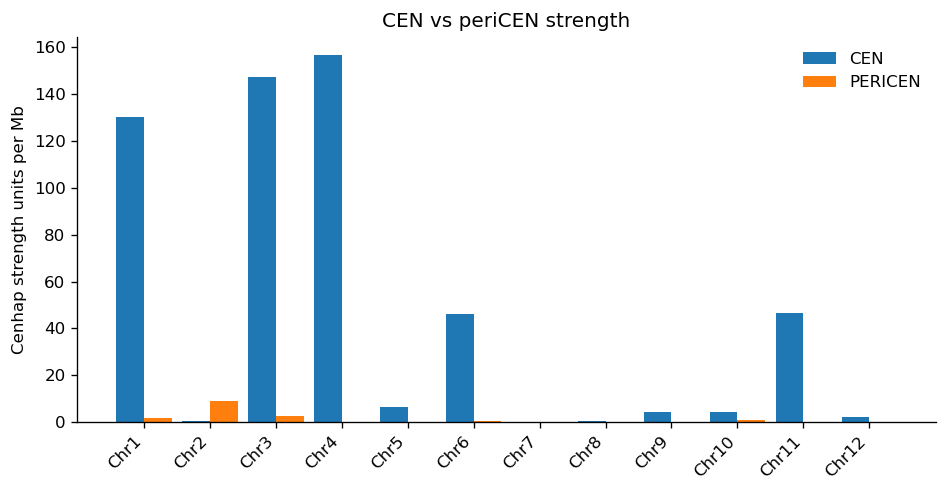

,chr,cen_region,pericen_region,cen_region_length_bp,pericen_region_length_bp,cen_cenhap_strength_units_per_mb,pericen_cenhap_strength_units_per_mb,pericen_to_cen_units_per_mb_ratio,cen_selected_distinct_kmers_per_mb,pericen_selected_distinct_kmers_per_mb,pericen_to_cen_selected_kmers_per_mb_ratio,stronger_region_by_units_per_mb
0,Chr1,CEN1,PERICEN1,1443060,4000000,130.278713,2.00,0.015352,352.029715,2.50,0.007102,CEN1
1,Chr2,CEN2,PERICEN2,1703558,4000000,0.587007,9.25,15.757912,0.587007,36.00,61.328088,PERICEN2
2,Chr3,CEN3,PERICEN3,1329118,4000000,147.466214,2.75,0.018648,323.522817,4.25,0.013137,CEN3
3,Chr4,CEN4,PERICEN4,1967076,4000000,156.577580,0.00,0.000000,702.057267,0.00,0.000000,CEN4
4,Chr5,CEN5,PERICEN5,1265754,4000000,6.320343,0.00,0.000000,8.690472,0.00,0.000000,CEN5
5,Chr6,CEN6,PERICEN6,1256734,4000000,46.151373,0.50,0.010834,142.432687,2.00,0.014042,CEN6
6,Chr7,CEN7,PERICEN7,1715729,4000000,0.000000,0.25,inf,0.000000,0.25,inf,PERICEN7
7,Chr8,CEN8,PERICEN8,1660441,4000000,0.602250,0.25,0.415110,0.602250,0.25,0.415110,CEN8
8,Chr9,CEN9,PERICEN9,1688676,4000000,4.145259,0.00,0.000000,6.513979,0.00,0.000000,CEN9
9,Chr10,CEN10,PERICEN10,1772716,4000000,4.512849,0.75,0.166192,6.205168,1.25,0.201445,CEN10


In [4]:
def chromosome_sort_key(value):
    text = str(value)
    match = re.search(r"(\d+)$", text)
    return (int(match.group(1)) if match else math.inf, text)

paired = tables.get("paired_cen_pericen_strength")
if paired is None or paired.empty:
    display(Markdown("No `*.paired_cen_pericen_strength.tsv` table found for this run."))
else:
    paired_plot = paired.copy()
    paired_plot["chr_sort"] = paired_plot["chr"].map(chromosome_sort_key)
    paired_plot = paired_plot.sort_values("chr_sort")

    x = np.arange(len(paired_plot))
    width = 0.42
    fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(paired_plot)), 4.2))
    ax.bar(x - width / 2, paired_plot["cen_cenhap_strength_units_per_mb"], width, label="CEN")
    ax.bar(x + width / 2, paired_plot["pericen_cenhap_strength_units_per_mb"], width, label="PERICEN")
    ax.set_xticks(x)
    ax.set_xticklabels(paired_plot["chr"], rotation=45, ha="right")
    ax.set_ylabel("Cenhap strength units per Mb")
    ax.set_title("CEN vs periCEN strength")
    ax.legend(frameon=False)
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIG_DIR / "cen_pericen_strength_units_per_mb.png", bbox_inches="tight")
    plt.show()

    display(paired_plot.drop(columns=["chr_sort"]))


## CEN/PERICEN similarity heatmap

This heatmap uses `*.cen_relatedness.idf_weighted_matrix.tsv`. Values are IDF-weighted Jaccard relatedness scores, where higher values mean more shared selected k-mer signal after downweighting broadly shared k-mers.


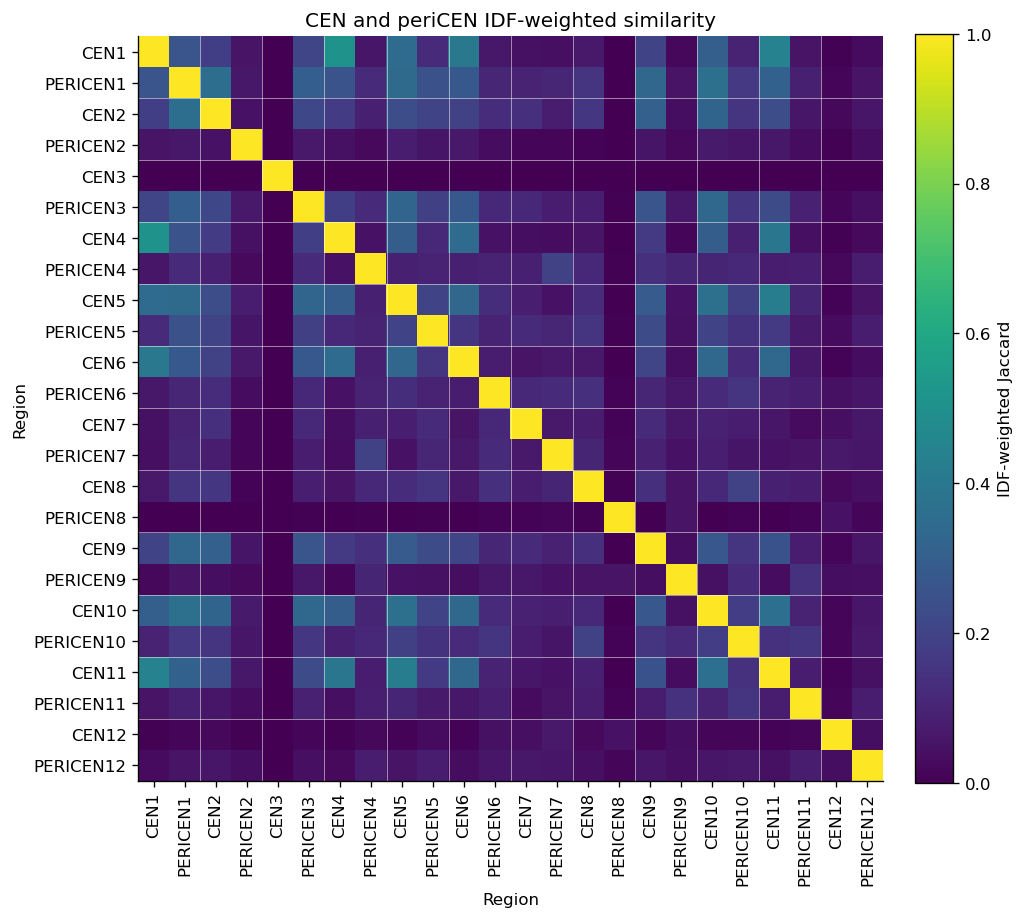

,CEN1,PERICEN1,CEN2,PERICEN2,CEN3,PERICEN3,CEN4,PERICEN4,CEN5,PERICEN5,...,CEN8,PERICEN8,CEN9,PERICEN9,CEN10,PERICEN10,CEN11,PERICEN11,CEN12,PERICEN12
assigned_cen,,,,,,,,,,,,,,,,,,,,,
CEN1,1.0000,0.2634,0.1855,0.0522,0.0000,0.2090,0.5086,0.0590,0.3481,0.1227,...,0.0672,0.0003,0.2068,0.0206,0.3011,0.0996,0.4424,0.0520,0.0059,0.0279
PERICEN1,0.2634,1.0000,0.3625,0.0631,0.0002,0.2991,0.2543,0.1212,0.3446,0.2472,...,0.1508,0.0036,0.3314,0.0537,0.3707,0.1649,0.3095,0.0893,0.0141,0.0532
CEN2,0.1855,0.3625,1.0000,0.0498,0.0001,0.2151,0.1744,0.0875,0.2377,0.2054,...,0.1571,0.0012,0.3051,0.0352,0.3209,0.1544,0.2350,0.0588,0.0214,0.0606
PERICEN2,0.0522,0.0631,0.0498,1.0000,0.0002,0.0692,0.0446,0.0246,0.0802,0.0553,...,0.0100,0.0032,0.0567,0.0255,0.0710,0.0617,0.0658,0.0323,0.0042,0.0370
CEN3,0.0000,0.0002,0.0001,0.0002,1.0000,0.0002,0.0000,0.0001,0.0001,0.0002,...,0.0002,0.0002,0.0000,0.0005,0.0001,0.0003,0.0000,0.0036,0.0000,0.0002
PERICEN3,0.2090,0.2991,0.2151,0.0692,0.0002,1.0000,0.1867,0.1180,0.3249,0.1887,...,0.0851,0.0041,0.2644,0.0631,0.3376,0.1574,0.2311,0.0917,0.0133,0.0425
CEN4,0.5086,0.2543,0.1744,0.0446,0.0000,0.1867,1.0000,0.0482,0.2962,0.1104,...,0.0520,0.0002,0.1681,0.0190,0.2959,0.0860,0.3923,0.0429,0.0056,0.0237
PERICEN4,0.0590,0.1212,0.0875,0.0246,0.0001,0.1180,0.0482,1.0000,0.0870,0.1014,...,0.1123,0.0058,0.1374,0.1020,0.1022,0.1115,0.0806,0.0842,0.0231,0.0753
CEN5,0.3481,0.3446,0.2377,0.0802,0.0001,0.3249,0.2962,0.0870,1.0000,0.2036,...,0.1265,0.0006,0.2871,0.0496,0.3680,0.1881,0.4206,0.1021,0.0102,0.0514


In [5]:
def cen_label_sort_key(label):
    text = str(label)
    match = re.search(r"(\d+)$", text)
    number = int(match.group(1)) if match else math.inf
    if text.startswith("PERICEN"):
        kind = 1
    elif text.startswith("CEN"):
        kind = 0
    else:
        kind = 2
    return (number, kind, text)


def load_relatedness_matrix(path):
    matrix = pd.read_csv(path, sep="	")
    first_col = matrix.columns[0]
    matrix = matrix.rename(columns={first_col: "assigned_cen"}).set_index("assigned_cen")
    matrix = matrix.apply(pd.to_numeric, errors="coerce")
    labels = [label for label in sorted(matrix.index, key=cen_label_sort_key) if label in matrix.columns]
    return matrix.loc[labels, labels]

matrix_path = paths.get("relatedness_matrix")
if matrix_path is None:
    display(Markdown("No `*.cen_relatedness.idf_weighted_matrix.tsv` table found for this run."))
else:
    sim = load_relatedness_matrix(matrix_path)
    n = len(sim)
    fig, ax = plt.subplots(figsize=(max(7.5, 0.36 * n), max(6.5, 0.34 * n)))
    vmax = max(1.0, float(np.nanmax(sim.to_numpy())))
    image = ax.imshow(sim.to_numpy(), cmap="viridis", vmin=0, vmax=vmax, aspect="equal")
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(sim.columns, rotation=90)
    ax.set_yticklabels(sim.index)
    ax.set_title("CEN and periCEN IDF-weighted similarity")
    ax.set_xlabel("Region")
    ax.set_ylabel("Region")

    # Draw light separators between chromosome pairs when labels are ordered as CENn/PERICENn.
    for boundary in np.arange(1.5, n - 0.5, 2):
        ax.axhline(boundary, color="white", linewidth=0.6, alpha=0.5)
        ax.axvline(boundary, color="white", linewidth=0.6, alpha=0.5)

    cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("IDF-weighted Jaccard")
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIG_DIR / "cen_pericen_idf_similarity_heatmap.png", bbox_inches="tight")
    plt.show()

    display(sim.round(4))


## Same-chromosome periCEN coupling

For periCEN-inclusive runs, this view compares each CEN's relatedness to its same-chromosome periCEN against cross-chromosome expectations.


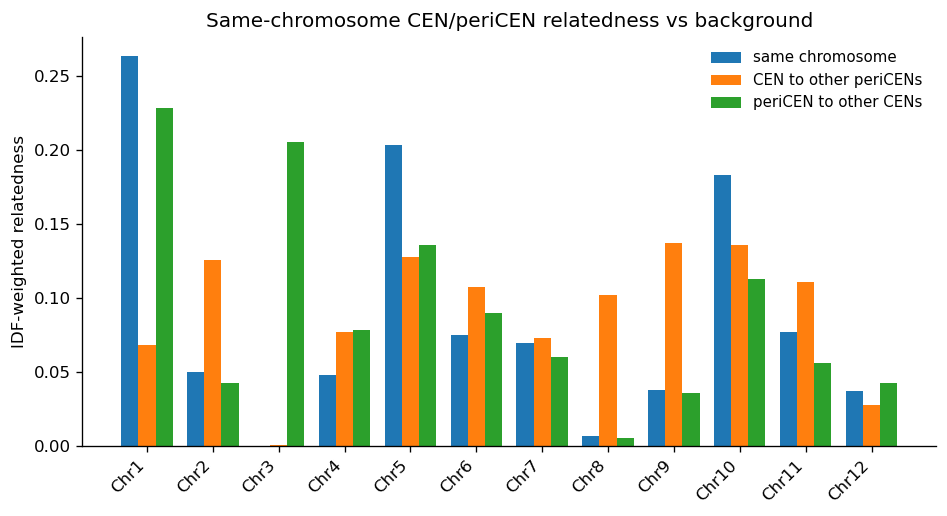

,chr,cen_region,pericen_region,same_chrom_cen_pericen_relatedness,mean_cen_to_other_pericens_relatedness,same_chrom_vs_cen_to_other_pericens_ratio,mean_pericen_to_other_cens_relatedness,same_chrom_vs_pericen_to_other_cens_ratio,mean_pericen_to_other_pericens_relatedness,mean_cen_to_other_cens_relatedness
0,Chr1,CEN1,PERICEN1,0.263397,0.068171,3.863794,0.228513,1.152657,0.119029,0.228023
1,Chr2,CEN2,PERICEN2,0.049811,0.126090,0.395043,0.042695,1.166673,0.038462,0.179094
2,Chr3,CEN3,PERICEN3,0.000196,0.000547,0.358725,0.205415,0.000956,0.111648,0.000039
3,Chr4,CEN4,PERICEN4,0.048234,0.077351,0.623567,0.078700,0.612877,0.094649,0.207061
4,Chr5,CEN5,PERICEN5,0.203606,0.127900,1.591918,0.135758,1.499771,0.103681,0.227835
5,Chr6,CEN6,PERICEN6,0.075367,0.107545,0.700799,0.090311,0.834533,0.085938,0.206801
6,Chr7,CEN7,PERICEN7,0.069647,0.073140,0.952243,0.060492,1.151343,0.078315,0.067887
7,Chr8,CEN8,PERICEN8,0.007149,0.101870,0.070173,0.005781,1.236572,0.012837,0.083637
8,Chr9,CEN9,PERICEN9,0.038284,0.137424,0.278585,0.035768,1.070340,0.068875,0.179427
9,Chr10,CEN10,PERICEN10,0.183232,0.135860,1.348680,0.112741,1.625249,0.108824,0.225143


In [6]:
ind = tables.get("cen_pericen_independence")
if ind is None or ind.empty:
    display(Markdown("No `*.cen_pericen_independence.tsv` table found for this run."))
else:
    ind_plot = ind.copy()
    ind_plot["chr_sort"] = ind_plot["chr"].map(chromosome_sort_key)
    ind_plot = ind_plot.sort_values("chr_sort")

    cols = [
        "same_chrom_cen_pericen_relatedness",
        "mean_cen_to_other_pericens_relatedness",
        "mean_pericen_to_other_cens_relatedness",
    ]
    labels = ["same chromosome", "CEN to other periCENs", "periCEN to other CENs"]
    x = np.arange(len(ind_plot))
    width = 0.26

    fig, ax = plt.subplots(figsize=(max(8, 0.65 * len(ind_plot)), 4.4))
    for offset, col, label in zip([-width, 0, width], cols, labels):
        ax.bar(x + offset, ind_plot[col], width, label=label)
    ax.set_xticks(x)
    ax.set_xticklabels(ind_plot["chr"], rotation=45, ha="right")
    ax.set_ylabel("IDF-weighted relatedness")
    ax.set_title("Same-chromosome CEN/periCEN relatedness vs background")
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIG_DIR / "cen_pericen_independence_relatedness.png", bbox_inches="tight")
    plt.show()

    display(ind_plot.drop(columns=["chr_sort"]))


## Other quick tables

A few compact summaries that are often useful before opening larger TSVs.


In [7]:
if "region_strength" in tables:
    region = tables["region_strength"].copy()
    display(Markdown("### Region strength sorted by strength units per Mb"))
    sort_col = "cenhap_strength_units_per_mb"
    display(region.sort_values(sort_col, ascending=False).head(20))

if "cenhap_unit_size_summary" in tables:
    display(Markdown("### Cenhap unit size summary"))
    display(tables["cenhap_unit_size_summary"].head(20))

if "cen_shared_kmer_sets" in tables:
    display(Markdown("### Shared k-mer set counts"))
    shared_sets = tables["cen_shared_kmer_sets"].copy()
    if "kmers" in shared_sets.columns:
        sort_cols = [col for col in ["present_all_core_cens", "present_all_pericens", "kmers"] if col in shared_sets.columns]
        ascending = [False] * len(sort_cols)
        shared_sets = shared_sets.sort_values(sort_cols, ascending=ascending) if sort_cols else shared_sets
    else:
        numeric_cols = shared_sets.select_dtypes(include="number").columns.tolist()
        if numeric_cols:
            shared_sets = shared_sets.sort_values(numeric_cols[-1], ascending=False)
    display(shared_sets.head(20))

    split_cols = [
        "present_region_class",
        "present_core_cens_count",
        "present_all_core_cens",
        "present_core_cens",
        "present_pericens_count",
        "present_all_pericens",
        "present_pericens",
        "kmers",
        "total_core_cen_hits",
        "total_pericen_hits",
    ]
    available_split_cols = [col for col in split_cols if col in shared_sets.columns]
    if available_split_cols:
        display(Markdown("### CEN/periCEN shared-kmer split summary"))
        display(shared_sets[available_split_cols].head(20))

if "cen_shared_kmers" in tables:
    shared_kmers = tables["cen_shared_kmers"].copy()
    required = {"present_all_core_cens", "present_all_pericens", "present_region_class"}
    if required.issubset(shared_kmers.columns):
        display(Markdown("### Shared k-mer classes by CEN/periCEN presence"))
        class_summary = (
            shared_kmers.groupby(
                ["present_region_class", "present_all_core_cens", "present_all_pericens"],
                dropna=False,
            )
            .size()
            .reset_index(name="kmers")
            .sort_values("kmers", ascending=False)
        )
        display(class_summary)

        example_cols = [
            "kmer",
            "present_region_class",
            "present_all_core_cens",
            "present_all_pericens",
            "present_core_cens",
            "present_pericens",
            "total_core_cen_hits",
            "total_pericen_hits",
            "shared_class",
            "present_cens",
        ]
        example_cols = [col for col in example_cols if col in shared_kmers.columns]
        all_core_not_all_pericen = shared_kmers[
            (shared_kmers["present_all_core_cens"] == 1)
            & (shared_kmers["present_all_pericens"] == 0)
        ]
        if not all_core_not_all_pericen.empty:
            display(Markdown("### Example k-mers present in all core CENs but not all periCENs"))
            display(all_core_not_all_pericen[example_cols].head(20))

if "kmer_summary" in tables:
    display(Markdown("### K-mer summary sample"))
    display(tables["kmer_summary"].head(20))


### Region strength sorted by strength units per Mb

,assigned_cen,region_class,chr,region_start,region_end,region_length_bp,selected_distinct_kmers,selected_distinct_kmers_per_mb,target_map_hits,target_map_hits_per_mb,cenhap_strength_units,cenhap_strength_units_per_mb,cenhap_strength_blocks,cenhap_strength_blocks_per_mb,block_bp,block_bp_fraction,mean_distinct_kmers_per_block
6,CEN4,CEN,Chr4,13368778,15335853,1967076,1381,702.057267,9845,5004.890508,308,156.577580,2714,1379.712833,139492,0.070913,3.627487
4,CEN3,CEN,Chr3,13060998,14390115,1329118,430,323.522817,5231,3935.692692,196,147.466214,3277,2465.544820,97221,0.073147,1.596277
0,CEN1,CEN,Chr1,39038122,40481181,1443060,508,352.029715,2855,1978.434715,188,130.278713,1146,794.145774,44628,0.030926,2.491274
20,CEN11,CEN,Chr11,22974707,24452507,1477801,161,108.945656,921,623.223289,69,46.690996,434,293.679596,15272,0.010334,2.122120
10,CEN6,CEN,Chr6,19435737,20692470,1256734,179,142.432687,869,691.474886,58,46.151373,291,231.552580,12743,0.010140,2.986254
3,PERICEN2,PERICEN,Chr2,14255916,19959473,4000000,144,36.000000,3206,801.500000,37,9.250000,2322,580.500000,62636,0.015659,1.380706
8,CEN5,CEN,Chr5,26943203,28208956,1265754,11,8.690472,54,42.662318,8,6.320343,40,31.601717,1060,0.000837,1.350000
18,CEN10,CEN,Chr10,23101665,24874380,1772716,11,6.205168,46,25.948883,8,4.512849,34,19.179609,972,0.000548,1.352941
16,CEN9,CEN,Chr9,19114559,20803234,1688676,11,6.513979,51,30.201175,7,4.145259,35,20.726297,1015,0.000601,1.457143
5,PERICEN3,PERICEN,Chr3,11060998,16390115,4000000,17,4.250000,124,31.000000,11,2.750000,109,27.250000,2657,0.000664,1.137615


### Cenhap unit size summary

,assigned_cen,units,singleton_units,fraction_singleton_units,total_distinct_kmers_in_units,min_distinct_kmers_per_unit,q25_distinct_kmers_per_unit,median_distinct_kmers_per_unit,q75_distinct_kmers_per_unit,max_distinct_kmers_per_unit,mean_distinct_kmers_per_unit,largest_unit_fraction_of_kmers,mean_target_map_hits_per_unit,mean_physical_blocks_per_unit
0,CEN1,188,79,0.420213,508,1,1.0,2.0,3.00,24,2.702128,0.047244,15.186170,6.095745
1,PERICEN1,8,6,0.750000,10,1,1.0,1.0,1.25,2,1.250000,0.200000,11.000000,8.000000
2,CEN2,1,1,1.000000,1,1,1.0,1.0,1.00,1,1.000000,1.000000,4.000000,4.000000
3,PERICEN2,37,16,0.432432,144,1,1.0,2.0,6.00,15,3.891892,0.104167,86.648649,62.756757
4,CEN3,196,108,0.551020,430,1,1.0,1.0,2.00,14,2.193878,0.032558,26.688776,16.719388
5,PERICEN3,11,8,0.727273,17,1,1.0,1.0,1.50,5,1.545455,0.294118,11.272727,9.909091
6,CEN4,308,98,0.318182,1381,1,1.0,2.0,5.00,87,4.483766,0.062998,31.964286,8.811688
7,PERICEN4,0,0,0.000000,0,0,0.0,0.0,0.00,0,0.000000,0.000000,0.000000,0.000000
8,CEN5,8,5,0.625000,11,1,1.0,1.0,2.00,2,1.375000,0.181818,6.750000,5.000000
9,PERICEN5,0,0,0.000000,0,0,0.0,0.0,0.00,0,0.000000,0.000000,0.000000,0.000000


### Shared k-mer set counts

,present_cens,present_cens_count,shared_class,kmers,selected_cenhap_defining_kmers,fraction_selected_cenhap_defining,total_core_hits,mean_total_core_hits_per_kmer,mean_idf_weight
3342,"PERICEN7,PERICEN10",2,subset_analysis_regions,1,1,1.000000,12,12.000000,3.120264
3341,"PERICEN2,PERICEN12",2,subset_analysis_regions,1,1,1.000000,21,21.000000,3.120264
3340,"PERICEN1,PERICEN7",2,subset_analysis_regions,1,1,1.000000,17,17.000000,3.120264
3339,"PERICEN1,PERICEN3",2,subset_analysis_regions,1,1,1.000000,16,16.000000,3.120264
3338,"CEN9,PERICEN10",2,subset_analysis_regions,1,1,1.000000,10,10.000000,3.120264
3337,"CEN12,PERICEN12",2,subset_analysis_regions,1,1,1.000000,11,11.000000,3.120264
3336,"PERICEN3,CEN9",2,subset_analysis_regions,4,4,1.000000,53,13.250000,3.120264
3335,"CEN3,PERICEN11",2,subset_analysis_regions,13,12,0.923077,155,11.923077,3.120264
3329,"PERICEN1,CEN2,CEN4",3,subset_analysis_regions,1,1,1.000000,10,10.000000,2.832581
3324,"CEN1,PERICEN3,CEN6",3,subset_analysis_regions,5,5,1.000000,50,10.000000,2.832581


### K-mer summary sample

,kmer,selected,fail_reasons,assigned_cen,total_map_hits,total_core_hits,target_core_hits,other_core_hits,max_other_core_hits,target_core_fraction,...,CEN8_hits,PERICEN8_hits,CEN9_hits,PERICEN9_hits,CEN10_hits,PERICEN10_hits,CEN11_hits,PERICEN11_hits,CEN12_hits,PERICEN12_hits
0,AAAAAAAATACGAGGCATAACAT,0,low_target_enrichment,CEN6,18,11,3,8,2,0.272727,...,0,0,1,0,0,0,2,0,0,0
1,AAAAAAATACGAGGCATAACATC,0,low_target_enrichment,CEN4,20,15,5,10,4,0.333333,...,0,0,0,0,1,0,2,0,0,0
2,AAAAAATACGAGGCATAACATCC,0,low_target_enrichment,CEN4,28,19,5,14,4,0.263158,...,1,0,0,0,1,0,1,2,0,0
3,AAAAAATGGTTTCCTATAGCACA,1,NaN,PERICEN2,10,10,10,0,0,1.000000,...,0,0,0,0,0,0,0,0,0,0
4,AAAAAATGGTTTGCTATAGCACA,1,NaN,PERICEN2,135,50,50,0,0,1.000000,...,0,0,0,0,0,0,0,0,0,0
5,AAAAAATTAAAAAGGGATCAGAT,1,NaN,CEN6,13,10,6,4,3,0.600000,...,0,0,0,0,0,0,0,0,0,0
6,AAAAAATTGGCATTTTTGACGTC,1,NaN,PERICEN2,56,19,19,0,0,1.000000,...,0,0,0,0,0,0,0,0,0,0
7,AAAAACAAATTCCAGCGAGGTCT,1,NaN,CEN4,23,12,4,8,2,0.333333,...,0,0,0,0,1,0,2,0,0,0
8,AAAAACACGCACCTGTAGCCCAA,0,low_target_enrichment,CEN11,19,11,3,8,2,0.272727,...,0,0,0,0,1,1,3,0,0,0
9,AAAAACACTTTGCACCCTGCAAC,0,low_target_enrichment,CEN1,18,10,3,7,3,0.300000,...,0,0,1,0,0,0,1,0,0,0
